# Homework 3

## 1 - Model selection for (polynomial) regression

In [1]:
# Load the dataset and split into X and y
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

seed = 67

data = pd.read_csv("poly_dataset.csv", sep=",", skiprows=1)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold

# Define the model Pipeline
model = Pipeline([
    ("polynomial", PolynomialFeatures()),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

# The double underscores are Pipeline syntax, so we know which parameters we are changing
param_grid = {
    "polynomial__degree": [1, 2, 3, 4, 5, 6],
    "ridge__alpha": [0, 0.001, 0.01, 0.1]
}

kf = KFold(n_splits=5, shuffle=True, random_state=seed)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error", # Negative because we look for the maximum score
    refit=True,
    cv=kf
)

# Fit the model to training data
grid_search.fit(X_train, y_train)

# Getting and printing all models and their mean scores
for i in range(len(param_grid["polynomial__degree"]) * len(param_grid["ridge__alpha"])):
    d = grid_search.cv_results_["param_polynomial__degree"][i]
    a = grid_search.cv_results_["param_ridge__alpha"][i]
    mean = grid_search.cv_results_["mean_test_score"][i]
    print(f"d={d}, a={a}, mean={-mean}")

print(grid_search.best_params_)
print(f"5-fold CV gives (mean) MSE: {-max(grid_search.cv_results_['mean_test_score'])} on validation data.")

d=1, a=0.0, mean=144.78941100880448
d=1, a=0.001, mean=144.7894093861752
d=1, a=0.01, mean=144.78939486058124
d=1, a=0.1, mean=144.7892573310859
d=2, a=0.0, mean=1.1936657895818081
d=2, a=0.001, mean=1.1936654726159464
d=2, a=0.01, mean=1.1936630107580104
d=2, a=0.1, mean=1.1936770048167529
d=3, a=0.0, mean=1.0236530822122942
d=3, a=0.001, mean=1.0236416053250306
d=3, a=0.01, mean=1.0235444835871423
d=3, a=0.1, mean=1.0231485017817954
d=4, a=0.0, mean=1.6452569242140869
d=4, a=0.001, mean=1.0475331786438582
d=4, a=0.01, mean=1.0464747695880017
d=4, a=0.1, mean=1.044136646256152
d=5, a=0.0, mean=1.5713974908373378
d=5, a=0.001, mean=1.088076388907505
d=5, a=0.01, mean=1.0778736487156997
d=5, a=0.1, mean=1.0606138740029234
d=6, a=0.0, mean=2.8160793593632087
d=6, a=0.001, mean=1.1427406722507882
d=6, a=0.01, mean=1.1172825436352354
d=6, a=0.1, mean=1.0924017417531047
{'polynomial__degree': 3, 'ridge__alpha': 0.1}
5-fold CV gives (mean) MSE: 1.0231485017817954 on validation data.


In [ ]:
# Testing my best model on the test set
from sklearn.metrics import mean_squared_error

# refit=True gives me the best model trained on all the training data from CV
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)

print(f"5-fold CV gives MSE: {MSE} on the test data.")

5-fold CV gives MSE: 1.0201705641434526 on the test data.


In [4]:
# Doing normal holdout-validation
X_train_resplit, X_val, y_train_resplit, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=seed)

degrees = [1, 2, 3, 4, 5, 6]
alphas = [0, 0.001, 0.01, 0.1]

best_score = np.inf
best_params = None

# Manual grid search
for d in degrees:
    for a in alphas:
        model = Pipeline([
            ("polynomial", PolynomialFeatures(d)),
            ("scaler", StandardScaler()),
            ("ridge", Ridge(a)),
        ])

        model.fit(X_train_resplit, y_train_resplit)
        y_pred = model.predict(X_val)
        MSE = mean_squared_error(y_val, y_pred)

        if MSE < best_score:
            best_score = MSE
            best_params = (d, a)

print(f"deg={best_params[0]}, alpha={best_params[1]}")
print(f"Manual splitting gives MSE: {best_score} on validation data.")

deg=3, alpha=0.1
Manual splitting gives MSE: 0.9004042180947611 on validation data.


In [5]:
d, a = best_params

model = Pipeline([
    ("polynomial", PolynomialFeatures(d)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(a)),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)

print(f"Manual splitting gives MSE: {MSE} on test data.")

Manual splitting gives MSE: 1.0201705641434526 on test data.


On question 1.6  
**How does MSE compare for the two methods?**  
MSE for the two methods is identical as they both end up picking the exact same hyperparameters.
For all seeds I tested it picked degree=3 and alpha=0.1 every time.

On question 1.7  
**Why is standardizing your features important when doing ridge regression?**  
Ridge regression's goal is to penalize large coefficients because a large coefficient is a sign that a model is trying to stretch the coefficient to fit the training data. The problem is that the size of a coefficient will vary depending on the range of the feature it is representing.  
Features with small ranges have large coefficients. (0.1 * 10 = 1)  
Features with large ranges have small coefficients. (10 * 0.1 = 1)  
Ridge regression would therefore have a bias against features with small ranges, as they always have bigger coefficients. This is not helpful.  
To combat this we center all features around 0 by setting their mean to 0, and scale them having a standard deviation of 1. This makes all features comparable to each other.  

**Should we put StandardScaler() before or after PolynomialFeatures()? What is the difference and does it really matter? (Test it!)**


In [6]:
# Testing


d = 10 # Testing for higher degrees since that is where the differences in coefficients will be bigger
a = 0.1

model_a = Pipeline([
    ("polynomial", PolynomialFeatures(d)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(a)),
])

model_b = Pipeline([
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(d)),
    ("ridge", Ridge(a)),
])

model_a.fit(X_train, y_train)
model_b.fit(X_train, y_train)

y_pred_a = model_a.predict(X_test)
y_pred_b = model_b.predict(X_test)

MSE_a = mean_squared_error(y_test, y_pred_a)
MSE_b = mean_squared_error(y_test, y_pred_b)

print(f"StandardScaler() after PolynomialFeatures() gives MSE = {MSE_a}")
print(f"StandardScaler() before PolynomialFeatures() gives MSE = {MSE_b}")

StandardScaler() after PolynomialFeatures() gives MSE = 1.167786312278771
StandardScaler() before PolynomialFeatures() gives MSE = 2.6670024267145944


We can see from the result that putting StandardScaler() after PolynomialFeatures() gives a better result. The reason for this that changing the order changes what is actually being scaled.  
If you put the StandardScaler() before PolynomialFeatures() you standardize the raw features x1 and x2 in this case. These features then go into PolynomialFeatures() which gives you back 1, x1, x2, x1*x2, x1^2, x2^2. These do not have the same scales.  
If you put the StandardScaler() after PolynomialFeatures() you standardize all the combinations of the raw features. This means that 1, x1, x2, x1*x2, x1^2 and x2^2 will all have the same scales.  
This does not look dramatic at d=3 (which is why I upped my testing to d=10), but the higher the number of degrees you have, the more dramatic the difference. This is because of how ridge regularization works, by penalizing large coefficients.

## 2 - Model selection for classification

In [7]:
from sklearn.datasets import make_classification

def make_dataset(r):
        """ Creates an unbalaced dataset with ratio r and returns X and y """
        X, y = make_classification(n_samples=1000, n_features=20, weights=[r], n_classes=2, random_state=seed)
        return X, y

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

def find_best_k(X_train, X_val, y_train, y_val):
    """ Takes in a dataset and returns the best value of k (num of neighbors) """

    best_k = None
    best_score = -np.inf
    ks = [1, 3, 5, 7, 9, 11, 13, 15] 

    for k in ks:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        score = accuracy_score(y_val, y_pred)
        if score > best_score:
            best_score = score
            best_k = k

    return best_k

BEST MODEL WITH RATIO 0.6:
Accuracy: 0.98
Balanced accuracy: 0.975
F1: 0.9743589743589743


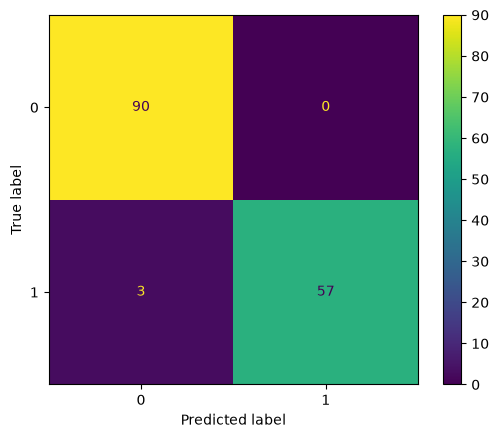





BEST MODEL WITH RATIO 0.75:
Accuracy: 0.9333333333333333
Balanced accuracy: 0.868421052631579
F1: 0.8484848484848485


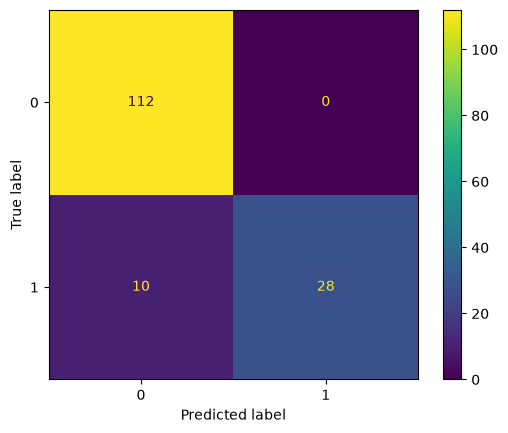





BEST MODEL WITH RATIO 0.9:
Accuracy: 0.94
Balanced accuracy: 0.7462686567164178
F1: 0.64


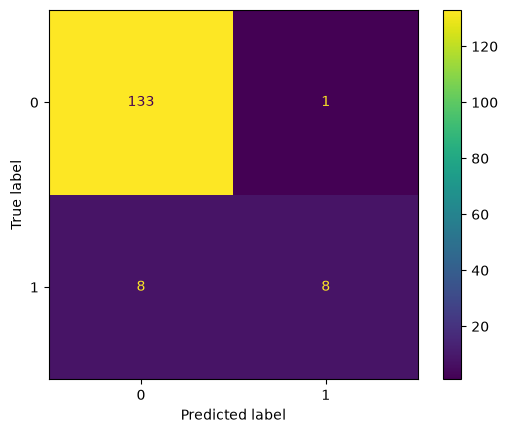





BEST MODEL WITH RATIO 0.95:
Accuracy: 0.9533333333333334
Balanced accuracy: 0.5625
F1: 0.2222222222222222


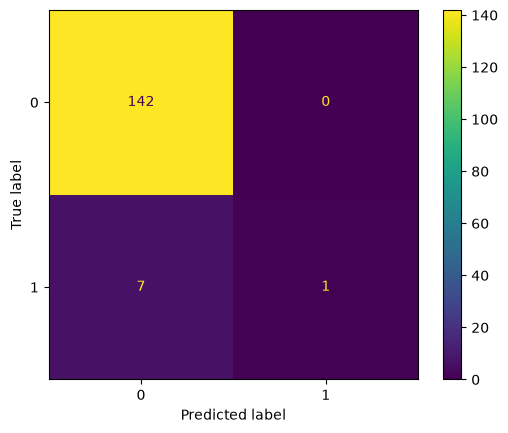





BEST MODEL WITH RATIO 0.98:
Accuracy: 0.9733333333333334
Balanced accuracy: 0.5
F1: 0.0


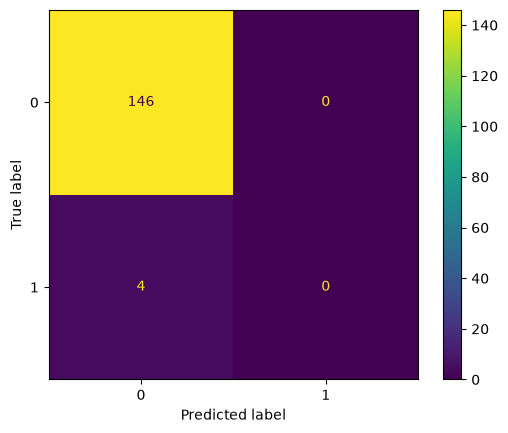





BEST MODEL WITH RATIO 0.99:
Accuracy: 0.9866666666666667
Balanced accuracy: 0.5
F1: 0.0


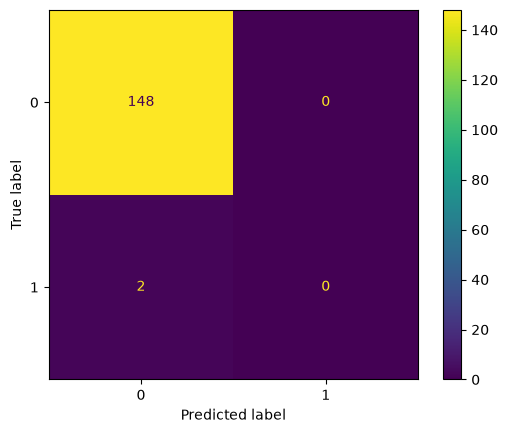

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ratios = [0.6, 0.75, 0.9, 0.95, 0.98, 0.99]
datasets = {}

accuracies = []
balanced_accuracies = []
f1s = []

# Loop over all ratios
for r in ratios:
    # Create dataset with this ratio
    X, y = make_dataset(r)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=seed, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15/0.85, random_state=seed, stratify=y_train_val)

    # Find the best value of k for this ratio
    best_k = find_best_k(X_train, X_val, y_train, y_val)

    # Create the model with the best value of k, fit it and test it
    best_model = KNeighborsClassifier(n_neighbors=best_k)
    best_model.fit(X_train_val, y_train_val)
    y_pred = best_model.predict(X_test)

    # Get accuracy, balanced accuracy and f1
    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Add them to my list for later plotting
    accuracies.append(accuracy)
    balanced_accuracies.append(balanced_accuracy)
    f1s.append(f1)


    print(f"BEST MODEL WITH RATIO {r}:")
    print(f"Accuracy: {accuracy}")
    print(f"Balanced accuracy: {balanced_accuracy}")
    print(f"F1: {f1}")

    # Creating and plotting confusion matrix for each ratio
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
    plt.show()
    print("\n\n\n")






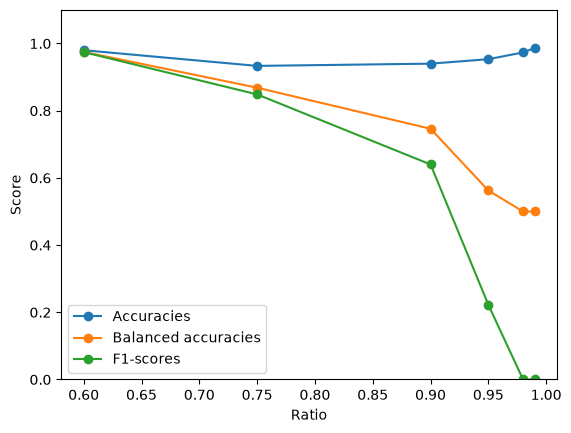

In [10]:
import matplotlib.pyplot as plt

plt.plot(ratios, accuracies, marker="o", label="Accuracies")
plt.plot(ratios, balanced_accuracies, marker="o", label="Balanced accuracies")
plt.plot(ratios, f1s, marker="o", label="F1-scores")
plt.ylim(0, 1.1)
plt.xlabel("Ratio")
plt.ylabel("Score")
plt.legend()
plt.show()

*Does the accuracy metric appear to assess the quality of your model in an appropriate way?*  
No, it does not.  
We can clearly see that as the ratio gets closer to 1, both balanced accuracy and f1 drop, while accuracy goes up. This means that we are guessing the majority class all the time, getting most of the minority class wrong.

### Using a predefined dataset

0: 9001
1: 999


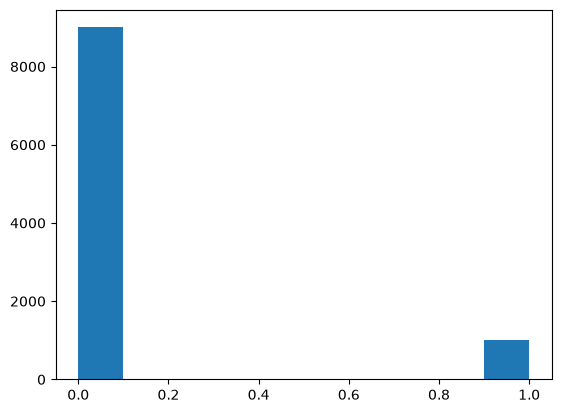

In [11]:
X, y = np.load("custom_unbalanced_dataset.pickle", allow_pickle=True)

values, counts = np.unique(y, return_counts=True)
print(f"{values[0]}: {counts[0]}\n{values[1]}: {counts[1]}")
plt.hist(y)
plt.show()

The dataset is very unbalanced, basically 90/10.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=seed, stratify=y)

Because the dataset is so unbalanced I decided to use F1 for CV. This means that both precision and recall have to be high for the score to be high.

In [13]:
model = KNeighborsClassifier()

param_grid={
    "n_neighbors": list(range(1, 20, 2))
}

grid_search = GridSearchCV(model, param_grid=param_grid, scoring="f1", refit=True, cv=10)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with higherva

In [14]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'n_neighbors': 17}
0.8691073263919238


F1: 0.8741721854304636


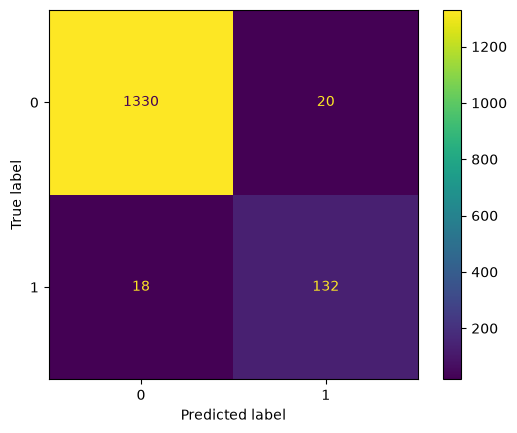

In [15]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f"F1: {f1}")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()